In [1]:
import os
import pandas as pd
import json

def discogs_to_dict(discogs_path: str) -> dict:
    dataset = {}
    with open(discogs_path, "r") as f:
        for line in f:
            clique = json.loads(line)
            clique_id = clique.pop("clique_id")
            dataset[clique_id] = clique
    return dataset

print("Load discogs...")
discogs = discogs_to_dict("data/discogs/Discogs-VI-YT-20240701.jsonl")


Load discogs...


In [ ]:
if not os.path.isfile("data/matched/filtered_max.csv"):
    print("Load matched...")
    df = pd.read_csv("data/matched/full.csv", sep="\t")
    df = df.drop("discogs_text", axis=1)
    df.youtube_id = df.youtube_id.astype("category")
    df.clique_id = df.clique_id.astype("category")
    df.youtube_attr = df.youtube_attr.astype("category")
    df.discogs_attr = df.discogs_attr.astype("category")
    print("Group...")
    grouped = (
    df.groupby(["youtube_id", "clique_id", "youtube_attr", "discogs_attr"], sort=False, observed=True)["Score"]
      .max()
    ).to_frame()
    grouped.to_csv("data/matched/filtered_max.csv", sep="\t")
else:
    print("Load matched grouped...")
    grouped = pd.read_csv("data/matched/filtered_max.csv", sep="\t")
    df = pd.read_csv("data/matched/full.csv", sep="\t")


Load matched grouped...


# Match Analysis
## Distributions per attribute combination

In [3]:
df_temp = grouped.copy()
df_temp = df_temp.reset_index()
df_temp["pair"] = df_temp.youtube_attr.astype("str") + " to " + df_temp.discogs_attr.astype("str")
df_temp["pair"] = df_temp["pair"].astype("category")


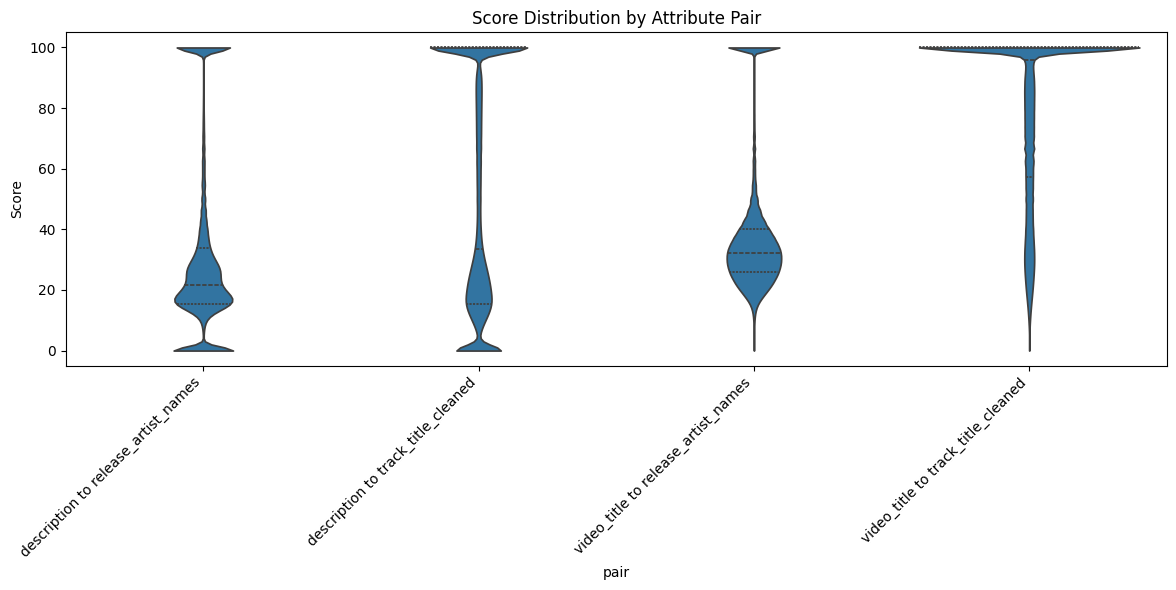

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.violinplot(x="pair", y="Score", data=df_temp, inner="quartile", cut=0)
plt.xticks(rotation=45, ha='right')
plt.title("Score Distribution by Attribute Pair")
plt.tight_layout()
plt.show()


## Sub-Groups
Given a relatively high minimum similarity, we split into the following groups:
- artist + title match
- only title match
- only artist match
- nothing matches 

In [ ]:
threshold = 80
df_temp = grouped.copy()
df_temp["Matched"] = df_temp["Score"] > threshold
df_temp = df_temp.reset_index()

pivot = df_temp.pivot_table(
    index=["youtube_id", "clique_id"],
    columns="discogs_attr",
    values="Matched",
    aggfunc="any",  # True if *any* row for that attr is matched
    fill_value=False,
    observed=True
)

def classify_match(row):
    artist = row.get("release_artist_names", False)
    title = row.get("track_title_cleaned", False)
    
    if artist and title:
        return "both"
    elif artist:
        return "only_release_artist_names"
    elif title:
        return "only_track_title_cleaned"
    else:
        return "none"

pivot["match_type"] = pivot.apply(classify_match, axis=1)
pivot.to_csv("data/matched/filtered_types.csv", sep="\t")

counts = pivot["match_type"].value_counts().reset_index()
counts['count'] = counts['count'].apply(lambda x: f"{x:,}")
print(counts)


                  match_type      count
0   only_track_title_cleaned  3,587,949
1                       none  2,420,306
2                       both  1,169,817
3  only_release_artist_names    198,138


## Get Sample for manuall annotation

In [ ]:
sample = pivot.groupby("match_type").sample(100)

sample = pd.merge(
    sample.reset_index(),
    df,
    on=["youtube_id", "clique_id"],
    how="left"
)
sample = sample.drop(columns=["youtube_attr", "Score"])
sample = sample.drop_duplicates()

discogs_attr_values = sample['discogs_attr'].unique().tolist()
group_cols = [col for col in sample.columns if col not in ['discogs_attr', 'discogs_text'] + discogs_attr_values]

# Pivot and aggregate
sample = sample.pivot_table(
    index=group_cols,
    columns='discogs_attr',
    values='discogs_text',
    aggfunc=lambda x: list(x),
    observed=True,
).reset_index()

sample.columns.name = None
sample.track_title_cleaned = sample.track_title_cleaned.apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)
sample = sample.sort_values(by=["match_type"])
sample.to_csv("data/matched/filtered_sample.csv", sep="\t", index=False)
sample


,youtube_id,clique_id,match_type,release_artist_names,track_title_cleaned
270,fl9_5drt5L4,C-0123739,both,"[Speedy West, Bob Wills & His Texas Playboys, ...",texas playboy rag
225,YE06PEENwu4,C-0109975,both,"[Enzo Di Domenico, Quartetto Enzo Gallo, Nando...",o ciucciariello
227,YOBfFYTGrNQ,C-0148423,both,"[Rachel Harrington, David Grisman, Mississippi...",louis collins
105,G-mxPDR7MCQ,C-0129599,both,[Beyoncé],get me bodied
235,Z4wzfDX7iXI,C-0066423,both,"[Lenny Dee, George Shearing, Bob Brookmeyer Qu...",honeysuckle rose
...,...,...,...,...,...
77,ApskeEy_e2g,C-0140723,only_track_title_cleaned,"[Emile Prud'Homme Et Son Ensemble, Tony Murena...",aubade doiseaux
279,hDfzaZI2AGM,C-0102880,only_track_title_cleaned,"[José Oliveira, Fafá De Belém, Carlos José, Ri...",ontem ao luar
281,hfR7g2SnM-M,C-0004607,only_track_title_cleaned,"[Soundgarden, Wood Witch, Exhorder, Cancer Bat...",into the void
80,BDCsM3uxK9I,C-0058782,only_track_title_cleaned,"[Lenny Dee, George Shearing, Liz Story, Bill R...",i got it bad
